# Experiment: Mediano Discrete Benchmark

这个 notebook 只保留实验一需要的两个核心输出：

- 一张带小写 `a-f` 子图编号的六联八节点示意总图；
- 一张双面板柱状图，同时汇总总 `EI` 与 `\Phi^{\mathrm{EID}}`。

新的 `E` 被改成“社区内更密、社区间仅有两条弱桥接边”的控制例子，用来说明局部高密度并不自动等于高整体协同。 


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    exp_candidate = candidate / "exp"
    if exp_candidate.exists():
        exp_candidate_str = str(exp_candidate)
        if exp_candidate_str not in sys.path:
            sys.path.insert(0, exp_candidate_str)
    if (candidate / "utils.py").exists():
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

from utils import (
    BENCHMARK_NETWORKS,
    compute_benchmark_results,
    export_benchmark_artifacts,
    export_benchmark_ei_phi_lollipop_artifacts,
    render_benchmark_topology_overview_svg,
    render_benchmark_ei_phi_summary_svg,
    render_metric_bar_chart_svg,
)

try:
    from IPython.display import SVG, display
except Exception:  # pragma: no cover - notebook fallback
    SVG = None
    display = print


## Six-network overview

下图把六个网络并排成一张完整总图，并统一用小写 `a-f` 标记子图编号。`e` 对应新的密社区弱桥接控制：两个 4 节点社区内部更密，但跨社区只有两条弱桥接边。 


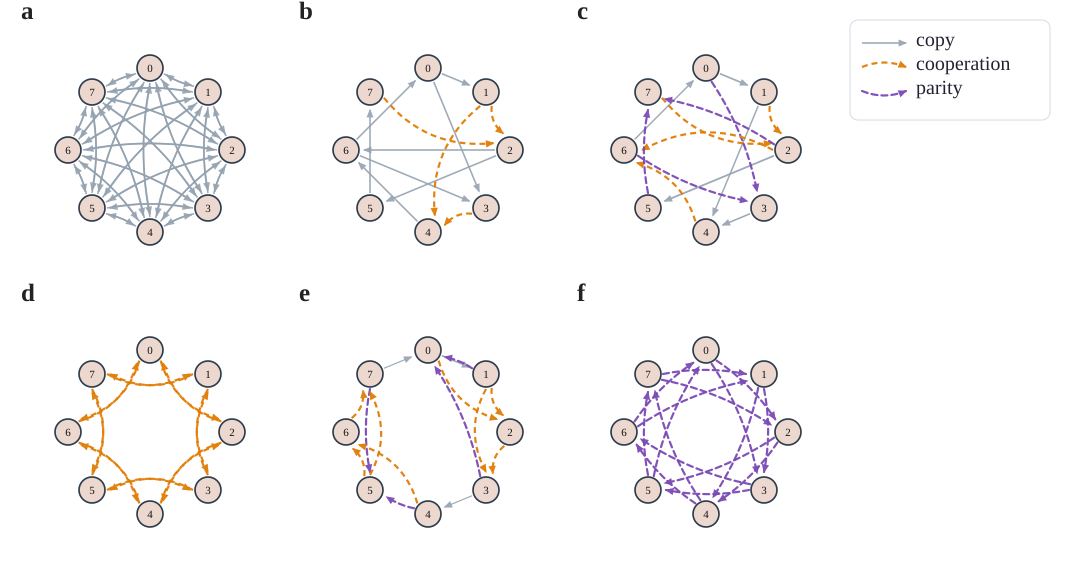

In [2]:
topology_layout_style = {
    "panel_width": 250,
    "panel_height": 250,
    "horizontal_gap": 14,
    "vertical_gap": 16,
    "outer_margin_x": 18,
    "outer_margin_y": 34,
}

topology_legend_style = {
    "show": True,
    "x": 350,
    "y": 5,
    "width": 446,
    "height": 27,
    "title": None,
    "title_font_size": 13,
    "item_font_size": 14,
    "item_spacing": 142,
    "orientation": "horizontal",
    "item_font_weight": "700",
}

topology_connection_style = {
    "copy": {
        "stroke": "#93a1af",
        "stroke_width_base": 1.05,
        "stroke_width_scale": 0.55,
        "start_offset": 15.0,
        "end_offset": 18.0,
        "bidirectional_curvature": 0.10,
        "marker_width": 8.6,
        "marker_height": 7.0,
        "marker_ref_x": 7.4,
        "marker_ref_y": 3.5,
        "marker_fill": "#93a1af",
    },
    "cooperation": {
        "stroke": "#e17c05",
        "stroke_width": 2.2,
        "dash": "6,4",
        "start_offset": 15.0,
        "end_offset": 18.0,
        "curvature": 0.27,
        "marker_width": 8.6,
        "marker_height": 7.4,
        "marker_ref_x": 7.5,
        "marker_ref_y": 3.7,
        "marker_fill": "#e17c05",
    },
    "parity": {
        "stroke": "#7b4ab5",
        "stroke_width": 2.2,
        "dash": "6,4",
        "start_offset": 15.0,
        "end_offset": 18.0,
        "curvature": 0.1,
        "marker_width": 8.6,
        "marker_height": 7.4,
        "marker_ref_x": 7.5,
        "marker_ref_y": 3.7,
        "marker_fill": "#7b4ab5",
    },
}

topology_connection_filter_style = {
    "drop_shared_parity_sources": True,
}

topology_label_style = {
    "show": True,
    "dx": 8,
    "dy": 32,
    "font_size": 30,
    "fill": "#111",
    "font_weight": "800",
}

topology_node_label_style = {
    "radius": 14.0,
    "font_size": 12.5,
    "font_weight": "700",
}

topology_overview_svg = render_benchmark_topology_overview_svg(
    BENCHMARK_NETWORKS,
    panel_width=topology_layout_style["panel_width"],
    panel_height=topology_layout_style["panel_height"],
    horizontal_gap=topology_layout_style["horizontal_gap"],
    vertical_gap=topology_layout_style["vertical_gap"],
    outer_margin_x=topology_layout_style["outer_margin_x"],
    outer_margin_y=topology_layout_style["outer_margin_y"],
    show_mechanism_legend=topology_legend_style["show"],
    mechanism_legend_x=topology_legend_style["x"],
    mechanism_legend_y=topology_legend_style["y"],
    mechanism_legend_width=topology_legend_style["width"],
    mechanism_legend_height=topology_legend_style["height"],
    mechanism_legend_title=topology_legend_style["title"],
    mechanism_legend_title_font_size=topology_legend_style["title_font_size"],
    mechanism_legend_item_font_size=topology_legend_style["item_font_size"],
    mechanism_legend_item_spacing=topology_legend_style["item_spacing"],
    mechanism_legend_orientation=topology_legend_style["orientation"],
    mechanism_legend_item_font_weight=topology_legend_style["item_font_weight"],
    node_radius=topology_node_label_style["radius"],
    node_label_font_size=topology_node_label_style["font_size"],
    node_label_font_weight=topology_node_label_style["font_weight"],
    connection_style=topology_connection_style,
    connection_filter_style=topology_connection_filter_style,
    show_panel_letters=topology_label_style["show"],
    panel_letter_dx=topology_label_style["dx"],
    panel_letter_dy=topology_label_style["dy"],
    panel_letter_font_size=topology_label_style["font_size"],
    panel_letter_fill=topology_label_style["fill"],
    panel_letter_font_weight=topology_label_style["font_weight"],
)
if SVG is not None:
    display(SVG(topology_overview_svg))
else:
    print(topology_overview_svg)


## Total EI and $\Phi^{\mathrm{EID}}$

下面两张柱状图只保留实验一正文真正要引用的两个系统级量：总 `EI` 与 `\Phi^{\mathrm{EID}}`，横轴标签也统一使用小写 `a-f`。 


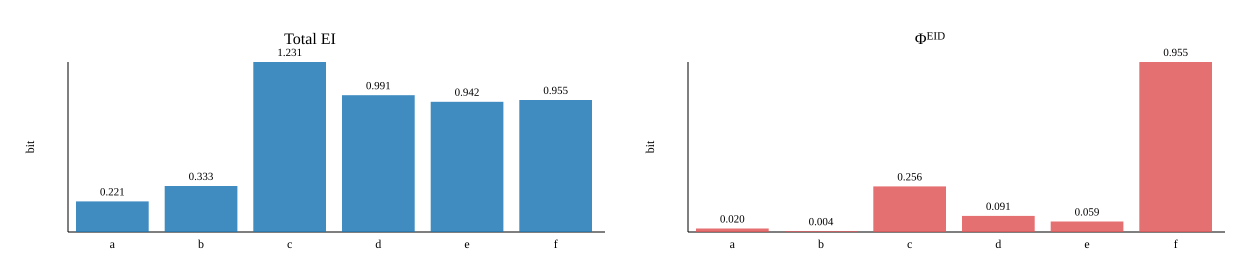

In [3]:
benchmark_results = compute_benchmark_results(BENCHMARK_NETWORKS)
ei_bar_chart_svg = render_metric_bar_chart_svg("ei", "Total EI", benchmark_results, color="#1F77B4")
phi_bar_chart_svg = render_metric_bar_chart_svg("phi_eid", r'$\Phi^{\mathrm{EID}}$', benchmark_results, color="#E15759")
ei_phi_summary_svg = render_benchmark_ei_phi_summary_svg(benchmark_results)
if SVG is not None:
    display(SVG(ei_phi_summary_svg))
else:
    print(ei_phi_summary_svg)


In [4]:
repo_root = next(candidate for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (candidate / "utils.py").exists())
artifact_dir = repo_root / "fig" / "mediano_discrete_benchmark"
publication_artifact_dir = repo_root / "fig" / "mediano_discrete_benchmark_publication"
export_benchmark_artifacts(
    artifact_dir,
    BENCHMARK_NETWORKS,
    benchmark_results,
    topology_overview_kwargs={
        "panel_width": topology_layout_style["panel_width"],
        "panel_height": topology_layout_style["panel_height"],
        "horizontal_gap": topology_layout_style["horizontal_gap"],
        "vertical_gap": topology_layout_style["vertical_gap"],
        "outer_margin_x": topology_layout_style["outer_margin_x"],
        "outer_margin_y": topology_layout_style["outer_margin_y"],
        "show_mechanism_legend": topology_legend_style["show"],
        "mechanism_legend_x": topology_legend_style["x"],
        "mechanism_legend_y": topology_legend_style["y"],
        "mechanism_legend_width": topology_legend_style["width"],
        "mechanism_legend_height": topology_legend_style["height"],
        "mechanism_legend_title": topology_legend_style["title"],
        "mechanism_legend_title_font_size": topology_legend_style["title_font_size"],
        "mechanism_legend_item_font_size": topology_legend_style["item_font_size"],
        "mechanism_legend_item_spacing": topology_legend_style["item_spacing"],
        "mechanism_legend_orientation": topology_legend_style["orientation"],
        "mechanism_legend_item_font_weight": topology_legend_style["item_font_weight"],
        "node_radius": topology_node_label_style["radius"],
        "node_label_font_size": topology_node_label_style["font_size"],
        "node_label_font_weight": topology_node_label_style["font_weight"],
        "connection_style": topology_connection_style,
        "connection_filter_style": topology_connection_filter_style,
        "show_panel_letters": topology_label_style["show"],
        "panel_letter_dx": topology_label_style["dx"],
        "panel_letter_dy": topology_label_style["dy"],
        "panel_letter_font_size": topology_label_style["font_size"],
        "panel_letter_fill": topology_label_style["fill"],
        "panel_letter_font_weight": topology_label_style["font_weight"],
    },
)
export_benchmark_ei_phi_lollipop_artifacts(
    publication_artifact_dir,
    benchmark_results,
    stem="ei_phi_publication_lollipop",
    write_source_data=True,
)
artifact_dir


PosixPath('fig/mediano_discrete_benchmark')